In [1]:
import torch
import time

device = "cuda"

# Large square matrix
N = 8192

dtype = torch.bfloat16

A = torch.randn(N, N, device=device, dtype=dtype)
B = torch.randn(N, N, device=device, dtype=dtype)

# Warmup
for _ in range(10):
    C = A @ B

torch.cuda.synchronize()

iters = 20

start = time.time()

for _ in range(iters):
    C = A @ B

torch.cuda.synchronize()

elapsed = time.time() - start

# GEMM FLOPs
flops = 2 * N**3 * iters

tflops = flops / elapsed / 1e12

print(f"Elapsed: {elapsed:.3f}s")
print(f"Achieved TFLOPS: {tflops:.2f}")

Elapsed: 0.954s
Achieved TFLOPS: 23.06


In [2]:
import torch
import time

device = "cuda"

N = 8192

dtype = torch.bfloat16

W = torch.randn(N, N, device=device, dtype=dtype)
x = torch.randn(N, device=device, dtype=dtype)

# Warmup
for _ in range(20):
    y = W @ x

torch.cuda.synchronize()

iters = 100

start = time.time()

for _ in range(iters):
    y = W @ x

torch.cuda.synchronize()

elapsed = time.time() - start

bytes_read = W.numel() * 2 * iters

gbps = bytes_read / elapsed / 1e9

print(f"Bandwidth = {gbps:.2f} GB/s")

Bandwidth = 160.41 GB/s


In [8]:
import torch
import time
import matplotlib.pyplot as plt

device = "cuda"

N = 8192
dtype = torch.bfloat16

W = torch.randn(N, N, device=device, dtype=dtype)

batch_sizes = [1,2,4,8,16,32,64,128,256,512,1024,2048]

tflops_results = []

for B in batch_sizes:

    X = torch.randn(N, B, device=device, dtype=dtype)

    for _ in range(10):
        Y = W @ X

    torch.cuda.synchronize()

    iters = 50

    start = time.time()

    for _ in range(iters):
        Y = W @ X

    torch.cuda.synchronize()

    elapsed = time.time() - start

    flops = 2 * N * N * B * iters

    tflops = flops / elapsed / 1e12

    tflops_results.append(tflops)

    print(B, tflops)

1 0.034513430990379027
2 0.48004600786331714
4 0.9619294182138851
8 2.3550449858655957
16 4.646910342327888
32 8.120153668043878
64 15.296643804700793
128 18.184422863253403
256 18.78691651664649
512 20.139633315052944
1024 22.499137531718468
2048 21.495228305062238


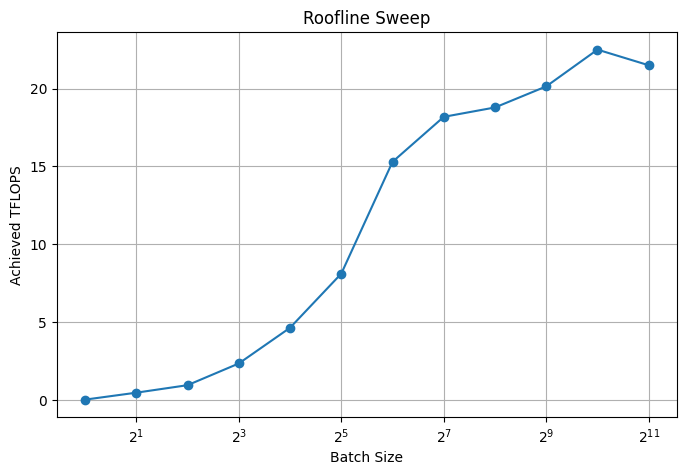

In [9]:
plt.figure(figsize=(8,5))

plt.plot(batch_sizes, tflops_results, marker='o')

plt.xscale("log", base=2)

plt.xlabel("Batch Size")
plt.ylabel("Achieved TFLOPS")

plt.title("Roofline Sweep")

plt.grid(True)

plt.show()

In [10]:
max_perf = max(tflops_results)

threshold = 0.90 * max_perf

ridge = None

for b, perf in zip(batch_sizes, tflops_results):
    if perf >= threshold:
        ridge = b
        break

print(f"Estimated Ridge Point = Batch {ridge}")

Estimated Ridge Point = Batch 1024
